In [1]:
import os
import pandas as pd
import time
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from scripts.train_model import circuit_training
from scr.qsvdd_core.data_loader import QuantumDataLoader
from scripts.test_model import test
import json

## Constants

In [2]:
dataset = 'fraud'
n_train = 0 ; latent_dim = 3
# num_params_conv = 375
cost_func = 'svdd'
learning_rate = 0.001

## Dataset

In [ ]:
print("Diretório atual:", os.getcwd())
print("Arquivos nesta pasta:", os.listdir())

In [3]:
file_path = os.path.join("..", "data", "creditcard.csv")
df = pd.read_csv(file_path)

print("Dataset carregado com sucesso!\n")
print("First 5 records:\n", df.head())

Dataset carregado com sucesso!

First 5 records:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141

In [ ]:
print(df.info())

In [ ]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

In [ ]:
plt.style.use('default')

sns.countplot(x='Class', data=df)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)

plt.show()

In [ ]:
tmp = df[['Amount','Class']].copy()
class_0 = tmp.loc[tmp['Class'] == 0]['Amount']
class_1 = tmp.loc[tmp['Class'] == 1]['Amount']

In [ ]:
class_0.describe()

In [ ]:
class_1.describe()

In [4]:
loader = QuantumDataLoader()

X_quantum, y = loader.prepare_fraud_data(df)

print(f"Features para o circuito: {X_quantum.shape}") # Deve mostrar (n_linhas, 32)
print(f"Labels: {y.shape}")

Features para o circuito: (284807, 32)
Labels: (284807,)


In [5]:
"""
One-class Training:
Separação em exemplos normais e fraudulentos
O QSVDD irá aprender o que é normal.
"""
normal_indices = np.where(y == 0)[0]
abnormal_indices = np.where(y == 1)[0]
np.random.seed(42)

# Treino
# coleta 1000 exemplos normais para o treino
X_train_normal_indices = np.random.choice(normal_indices, 1000, replace=False)
X_train_normal = X_quantum[X_train_normal_indices]
y_train_normal = y[X_train_normal_indices]

# X_train contém apenas transações legítimas
X_train = X_train_normal
Y_train = y_train_normal

# Teste (balanceado)
# O código retira 100 exemplos normais que não foram usados no treino
remaining_normal_indices = list(set(normal_indices) - set(X_train_normal_indices))
X_test_normal_indices = np.random.choice(remaining_normal_indices, 100, replace=False)
X_test_normal = X_quantum[X_test_normal_indices]
y_test_normal = y[X_test_normal_indices]

# O código retira 100 exemplos de fraudes.
X_test_abnormal_indices = np.random.choice(abnormal_indices, 100, replace=False)
X_test_abnormal = X_quantum[X_test_abnormal_indices]
y_test_abnormal = y[X_test_abnormal_indices]

# cria um conjunto de teste com 200 exemplos (50% normal, 50% fraude)
X_test = np.concatenate((X_test_normal, X_test_abnormal), axis=0)
Y_test = np.concatenate((y_test_normal, y_test_abnormal), axis=0)


center = np.zeros(latent_dim)
center_train = np.tile(center, (len(X_train), 1))


print(f'X_train shape: {X_train.shape}')
print(f'Y_train shape: {Y_train.shape}')
print(f'X_test_normal shape: {X_test_normal.shape}')
print(f'X_test_abnormal shape: {X_test_abnormal.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Y_test shape: {Y_test.shape}')
print(f'center_train shape: {center_train.shape}')

X_train shape: (1000, 32)
Y_train shape: (1000,)
X_test_normal shape: (100, 32)
X_test_abnormal shape: (100, 32)
X_test shape: (200, 32)
Y_test shape: (200,)
center_train shape: (1000, 3)


### Noiseless Training

In [ ]:
train_Xdata = X_train
train_Ydata = center_train

#### QCNN Ansatz

In [ ]:
qcnn_batch_size = 4
qcnn_steps = 16*500//qcnn_batch_size

In [ ]:
qcnn_start_time = time.time()
qcnn_loss_history, qcnn_est_params, qcnn_param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qcnn_batch_size,
                     learning_rate=learning_rate,
                     steps=qcnn_steps,
                     ansatz='qcnn'
                     )
)
qcnn_end_time = time.time()

qcnn_total_runtime = (qcnn_end_time - qcnn_start_time) / 60
print(f"Total runtime: {qcnn_total_runtime} minutes for batch size {qcnn_batch_size}")

Saving Noiseless Training with QCNN ansatz

In [ ]:
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_LOSS_HISTORY.npy", qcnn_loss_history)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_EST_PARAMS.npy", qcnn_est_params)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_PARAM_HISTORY.npy", qcnn_param_history)

#### QAE Ansatz

In [ ]:
qae_batch_size = 4
qae_steps = 16 * 500 // qae_batch_size

In [ ]:
qae_start_time = time.time()
qae_loss_history, qae_est_params, qae_param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qae_batch_size,
                     learning_rate=learning_rate,
                     steps=qae_steps,
                     ansatz='qae'
                     )
)
qae_end_time = time.time()

qae_total_runtime = (qae_end_time - qae_start_time) / 60
print(f"Total runtime: {qae_total_runtime} minutes for batch size {qae_batch_size}")

saving noiseless training with QAE Ansatz

In [ ]:
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_LOSS_HISTORY.npy", qae_loss_history)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_EST_PARAMS.npy", qae_est_params)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_PARAM_HISTORY.npy", qae_param_history)

#### LCQHNN Ansatz

In [116]:
# best batch_size = 64
lcqhnn_batch_size = 64
lcqhnn_steps = 16*500//lcqhnn_batch_size

In [ ]:
lcqhnn_start_time = time.time()
lcqhnn_loss_history, lcqhnn_est_params, lcqhnn_param_history = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=lcqhnn_batch_size,
                     learning_rate=learning_rate,
                     steps=lcqhnn_steps,
                     ansatz='lcqhnn'
                     )
)
lcqhnn_end_time = time.time()

lcqhnn_total_runtime = (lcqhnn_end_time - lcqhnn_start_time) / 60
print(f"Total runtime: {lcqhnn_total_runtime} minutes for batch size {lcqhnn_batch_size}")

saving noiseless training with QAE Ansatz

In [ ]:
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_LOSS_HISTORY.npy", lcqhnn_loss_history)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_EST_PARAMS.npy", lcqhnn_est_params)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_PARAM_HISTORY.npy", lcqhnn_param_history)

### Noisy Training

#### QCNN Ansatz noisy training

In [ ]:
qcnn_start_time_noise = time.time()
qcnn_loss_history_noise, qcnn_est_params_noise, qcnn_param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qcnn_batch_size,
                     learning_rate=learning_rate,
                     steps=qcnn_steps,
                     noisy=True,
                     ansatz='qcnn'
                     )
)
qcnn_end_time_noise = time.time()

qcnn_total_runtime_noise = (qcnn_end_time_noise - qcnn_start_time_noise) / 60
print(f"Total runtime: {qcnn_total_runtime_noise} minutes for batch size {qcnn_batch_size}")

Saving QCNN ansatz Noisy Training

In [ ]:
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_LOSS_HISTORY.npy", qcnn_loss_history_noise)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_EST_PARAMS.npy", qcnn_est_params_noise)
np.savetxt(f"../results/training/QCNN/QCNN_B{qcnn_batch_size:02d}S{qcnn_steps}_NOISE_PARAM_HISTORY.npy", qcnn_param_history_noise)

#### QAE Ansatz noisy training

In [ ]:
qae_start_time_noise = time.time()
qae_loss_history_noise, qae_est_params_noise, qae_param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=qae_batch_size,
                     learning_rate=learning_rate,
                     steps=qae_steps,
                     noisy=True,
                     ansatz='qae'
                     )
)
qae_end_time_noise = time.time()

qae_total_runtime_noise = (qae_end_time_noise - qae_start_time_noise) / 60
print(f"Total runtime: {qae_total_runtime_noise} minutes for batch size {qae_batch_size}")

saving noisy training with QAE Ansatz

In [ ]:
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_LOSS_HISTORY.npy", qae_loss_history_noise)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_EST_PARAMS.npy", qae_est_params_noise)
np.savetxt(f"../results/training/QAE/QAE_B{qae_batch_size:02d}S{qae_steps}_NOISE_PARAM_HISTORY.npy", qae_param_history_noise)

#### LCQHNN Ansatz noisy training

In [117]:
lcqhnn_start_time_noise = time.time()
lcqhnn_loss_history_noise, lcqhnn_est_params_noise, lcqhnn_param_history_noise = (
    circuit_training(X_train=train_Xdata,
                     Y_train=train_Ydata,
                     batch_size=lcqhnn_batch_size,
                     learning_rate=learning_rate,
                     steps=lcqhnn_steps,
                     noisy=True,
                     ansatz='lcqhnn'
                     )
)
lcqhnn_end_time_noise = time.time()

lcqhnn_total_runtime_noise = (lcqhnn_end_time_noise - lcqhnn_start_time_noise) / 60
print(f"Total runtime: {lcqhnn_total_runtime_noise} minutes for batch size {lcqhnn_batch_size}")

iteration: 0 | cost: 0.003849
iteration: 1 | cost: 0.003551
iteration: 2 | cost: 0.003856
iteration: 3 | cost: 0.003617
iteration: 4 | cost: 0.003507
iteration: 5 | cost: 0.003658
iteration: 6 | cost: 0.003801
iteration: 7 | cost: 0.003433
iteration: 8 | cost: 0.003374
iteration: 9 | cost: 0.003219
iteration: 10 | cost: 0.003473
iteration: 11 | cost: 0.003304
iteration: 12 | cost: 0.003134
iteration: 13 | cost: 0.003180
iteration: 14 | cost: 0.003129
iteration: 15 | cost: 0.003076
iteration: 16 | cost: 0.002993
iteration: 17 | cost: 0.002899
iteration: 18 | cost: 0.003438
iteration: 19 | cost: 0.003149
iteration: 20 | cost: 0.003010
iteration: 21 | cost: 0.002985
iteration: 22 | cost: 0.002700
iteration: 23 | cost: 0.002729
iteration: 24 | cost: 0.002943
iteration: 25 | cost: 0.003162
iteration: 26 | cost: 0.002683
iteration: 27 | cost: 0.002468
iteration: 28 | cost: 0.002741
iteration: 29 | cost: 0.002763
iteration: 30 | cost: 0.002468
iteration: 31 | cost: 0.002348
iteration: 32 | co

In [119]:
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_LOSS_HISTORY.npy", lcqhnn_loss_history_noise)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_EST_PARAMS.npy", lcqhnn_est_params_noise)
np.savetxt(f"../results/training/LCQHNN/LCQHNN_B{lcqhnn_batch_size:02d}S{lcqhnn_steps}_NOISE_PARAM_HISTORY.npy", lcqhnn_param_history_noise)

## Noiseless Test

método para encontrar o melhor batch

In [6]:
def best_batch(method='qcnn'):
    method_upper = method.upper()

    variations = [
    "B04S2000",
    "B08S1000",
    "B16S500",
    "B32S250",
    "B64S125",
    ]

    test_results = {}

    for var in variations:
        f_name = f"../results/training/{method_upper}/{method_upper}_{var}_EST_PARAMS.npy"


        try:
            qae_est_params = np.loadtxt(f_name)

            auc, y_pred, y_true, fpr, tpr = test(
                n_train, X_test, Y_test, qae_est_params, center_train, ansatz=method
            )


            # 4. Armazena no dicionário usando a variação como chave
            test_results[var] = {
                "auc": auc,
                "y_pred": y_pred,
                "y_true": y_true,
                "fpr": fpr,
                "tpr": tpr
            }

            print(f"Concluído: QSVDD: {method_upper} ANSATZ - {var} | AUC: {auc:.4f}")
            print("\n" + 50*"=" + "\n")

        except FileNotFoundError:
            print(f"Erro: Arquivo {f_name} não encontrado.")
        except Exception as e:
            print(f"Erro ao processar {var}: {e}")

    return test_results


In [7]:
def save_test_results(resultados_test, method='qcnn'):

    upper_method = method.upper()

    # 1. Encontrar a configuração com o maior AUC
    melhor_config = max(resultados_test, key=lambda k: resultados_test[k]['auc'])
    dados_vencedor = resultados_test[melhor_config]

    print(f"🏆 O melhor modelo foi: {melhor_config} com AUC = {dados_vencedor['auc']:.4f}")

    # 2. Salvar o dicionário completo (opcional, em formato JSON para leitura fácil)
    # Nota: convertemos arrays numpy para listas para o JSON aceitar
    full_results_serializable = {
        k: {
            "auc": v["auc"],
            "fpr": v["fpr"].tolist() if isinstance(v["fpr"], np.ndarray) else v["fpr"],
            "tpr": v["tpr"].tolist() if isinstance(v["tpr"], np.ndarray) else v["tpr"]
        } for k, v in resultados_test.items()
    }

    with open(f"../results/test/All_Results_{upper_method}.json", "w") as f:
        json.dump(full_results_serializable, f, indent=4)

    # 3. Salvar apenas os dados do melhor resultado para uso posterior
    np.save(f"../results/test/BEST_{upper_method}_{melhor_config}_METRICS.npy", {
        "auc": dados_vencedor["auc"],
        "fpr": dados_vencedor["fpr"],
        "tpr": dados_vencedor["tpr"],
        "y_pred": dados_vencedor["y_pred"],
        "y_true": dados_vencedor["y_true"]
    })

    # 4. Salvar um resumo em texto para o seu relatório
    with open(f"../results/test/{upper_method}resumo_performance.txt", "w") as f:
        f.write(f"Relatório de Performance - Ansatz: {upper_method}\n")
        f.write(f"Melhor Configuracao: {melhor_config}\n")
        f.write(f"AUC Maximo: {dados_vencedor['auc']}\n")
        f.write("-" * 30 + "\n")
        for config, dados in resultados_test.items():
            f.write(f"{config}: AUC = {dados['auc']:.4f}\n")

    print("✅ Todos os arquivos foram salvos com sucesso.")

#### QCNN Ansatz noiseless Test

definindo melhor batch

In [ ]:
qcnn_test_best_batch = best_batch(method='qcnn')

In [ ]:
save_test_results(qcnn_test_best_batch, method='qcnn')

In [ ]:
best_qcnn = 'B04S2000'
f_name = f"../results/training/QCNN/QCNN_{best_qcnn}_EST_PARAMS.npy"
qae_est_params = np.loadtxt(f_name)

auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, qae_est_params, center_train, ansatz='qcnn')

#### QAE Ansatz noiseless Test

definindo melhor batch

In [ ]:
qae_test_best_batch = best_batch(method='qae')

In [ ]:
save_test_results(qae_test_best_batch, method='qae')

Melhor batch: 4

In [41]:
f_name = "../results/training/QAE/QAE_B04S2000_EST_PARAMS.npy"
qae_est_params = np.loadtxt(f_name)

auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, qae_est_params, center_train, ansatz='qae')

Processing class 0 (label 0) | Samples: 100
Finished class 0 in 1.32s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 1.31s
Test completed in 2.64s | AUC: 0.9280


#### LCQHNN Ansatz noiseless Test

definindo melhor batch

In [8]:
lcqhnn_test_best_batch = best_batch(method='lcqhnn')

Processing class 0 (label 0) | Samples: 100
Finished class 0 in 0.72s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 0.72s
Test completed in 1.44s | AUC: 0.7626
Concluído: QSVDD: LCQHNN ANSATZ - B04S2000 | AUC: 0.7626


Processing class 0 (label 0) | Samples: 100
Finished class 0 in 0.72s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 0.70s
Test completed in 1.42s | AUC: 0.7618
Concluído: QSVDD: LCQHNN ANSATZ - B08S1000 | AUC: 0.7618


Processing class 0 (label 0) | Samples: 100
Finished class 0 in 0.70s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 0.71s
Test completed in 1.41s | AUC: 0.9035
Concluído: QSVDD: LCQHNN ANSATZ - B16S500 | AUC: 0.9035


Processing class 0 (label 0) | Samples: 100
Finished class 0 in 0.70s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 0.71s
Test completed in 1.41s | AUC: 0.9074
Concluído: QSVDD: LCQHNN ANSATZ - B32S250 | AUC: 0.9074


Processing class 0 (label 0) | Samples: 100
Finished c

In [10]:
save_test_results(lcqhnn_test_best_batch, method='lcqhnn')

🏆 O melhor modelo foi: B32S250 com AUC = 0.9074
✅ Todos os arquivos foram salvos com sucesso.


## Saving Noiseless Test

In [ ]:
# file_name = f"B{qae_batch_size:02d}S{qae_steps}.txt"
# results_dir = os.path.join("..", "results", "test")
# file_path = os.path.join(results_dir, file_name)
#
# os.makedirs(results_dir, exist_ok=True)
#
# with open(file_path, "w") as f:
#     f.write("Test completed.\n")
#     f.write(f"Batch Size = {qae_batch_size} \nSteps = {qae_steps} \n")
#     # f.write(f"Training time: {total_runtime:.2f} minutes\n")
#     f.write(f"AUC: {auc:.4f}\n")
#
#
# print(f"Success! Result saved to: {file_path}")
# # print(f"Training time: {total_runtime:.2f} minutes")
# print(f"AUC Score: {auc:.4f}")

(array([151.,  20.,  13.,   0.,   9.,   1.,   4.,   1.,   0.,   1.]),
 array([2.49914014e-06, 4.42422676e-03, 8.84595438e-03, 1.32676820e-02,
        1.76894096e-02, 2.21111372e-02, 2.65328649e-02, 3.09545925e-02,
        3.53763201e-02, 3.97980477e-02, 4.42197753e-02]),
 <BarContainer object of 10 artists>)

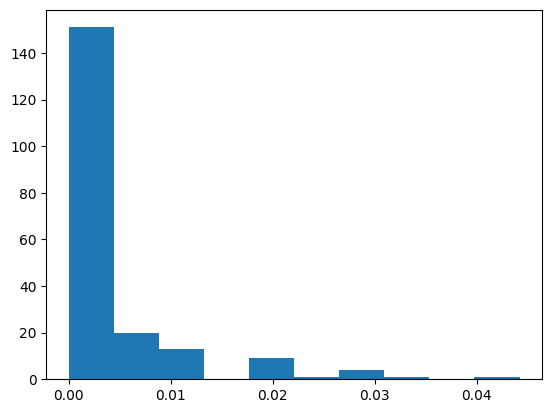

In [42]:
plt.hist(y_pred)

2026-02-11; 16:16:21


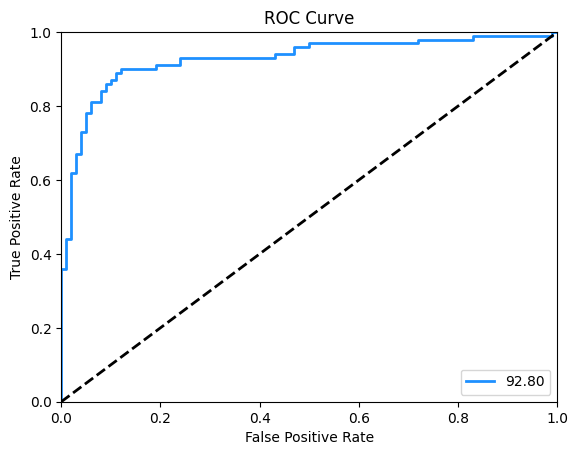

In [43]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d; %H:%M:%S")
print(timestamp)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="{:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## Noisy Test

In [23]:
auc, y_pred, y_true, fpr, tpr = test(n_train, X_test, Y_test, qae_est_params_noise, center_train, noisy=True)

Processing class 0 (label 0) | Samples: 100
Finished class 0 in 36.53s
Processing class 1 (label 1) | Samples: 100
Finished class 1 in 37.64s
Test completed in 74.18s | AUC: 0.8740


## Saving Noisy Test

In [24]:
file_name = f"B{qae_batch_size:02d}S{qae_steps}_NOISY.txt"
results_dir = os.path.join("..", "results", "test")
file_path = os.path.join(results_dir, file_name)

os.makedirs(results_dir, exist_ok=True)

with open(file_path, "w") as f:
    f.write("Test completed.\n")
    f.write(f"Batch Size = {qae_batch_size} \nSteps = {qae_steps} \n")
    f.write(f"Training time: {total_runtime:.2f} minutes\n")
    f.write(f"AUC: {auc:.4f}\n")

print(f"Success! Result saved to: {file_path}")
print(f"Training time: {total_runtime:.2f} minutes")
print(f"AUC Score: {auc:.4f}")

Success! Result saved to: ../results/test/batch04_steps500_noisy.txt
Training time: 30.72 minutes
AUC Score: 0.8740


(array([146.,  25.,  12.,   3.,   3.,   0.,   5.,   3.,   1.,   2.]),
 array([4.31454564e-06, 3.80379775e-04, 7.56445005e-04, 1.13251023e-03,
        1.50857546e-03, 1.88464069e-03, 2.26070592e-03, 2.63677115e-03,
        3.01283638e-03, 3.38890161e-03, 3.76496684e-03]),
 <BarContainer object of 10 artists>)

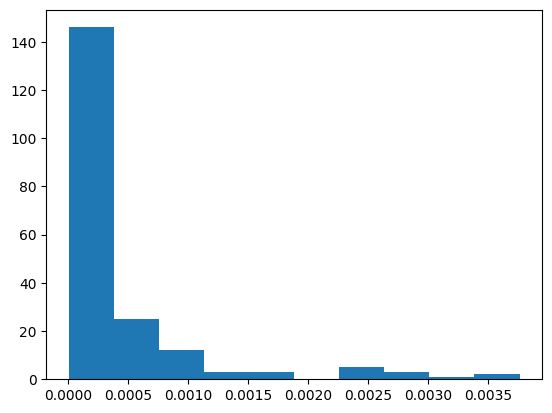

In [25]:
plt.hist(y_pred)

2026-02-05; 15:49:05


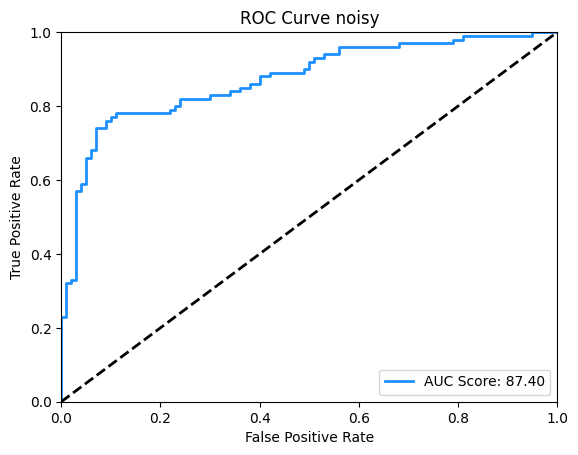

In [26]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y-%m-%d; %H:%M:%S")
print(timestamp)
plt.figure()
lw = 2
plt.plot(fpr, tpr, color='dodgerblue', lw=lw, label="AUC Score: {:.2f}".format(auc * 100))
plt.plot([0, 1], [0, 1], color="black", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve noisy")
plt.legend(loc="lower right")
plt.show()